In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

c:\Users\roysu\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading Dataset ##

In [2]:
anime_df = pd.read_csv("anime.csv")
rating_df = pd.read_csv("rating.csv")

In [3]:
rating_df.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [4]:
anime_profile = ProfileReport(anime_df,title="Anime Data Profiling Report",explorative=True)

In [5]:
ratings_profile = ProfileReport(rating_df, title="Rating Data Profiling Report")

In [6]:
anime_profile.to_file("Anime_profile_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 59.87it/s]


In [7]:
ratings_profile.to_file("Ratings_profile_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 1335.77it/s]


In [8]:
anime_df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [9]:
anime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [10]:
anime_df.describe(include='object')

,name,genre,type,episodes
count,12294,12232,12269,12294
unique,12292,3264,6,187
top,Shi Wan Ge Leng Xiaohua,Hentai,TV,1
freq,2,823,3787,5677


In [11]:
rating_df.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


## Data Cleaning ##



ANIME_DF

- Name duplicates there
- ~~62 missing values in Genre~~
- ~~25 missing values in Type~~
- ~~Rating 230 vales missing values and has left skewed distribution~~ 

RATING_DF

- 1 Duplicate row
- Rating range [-1,10] where negative has large quantity 	1476496


In [12]:
anime_df['rating'].fillna(anime_df['rating'].median())

0        9.37
1        9.26
2        9.25
3        9.17
4        9.16
         ... 
12289    4.15
12290    4.28
12291    4.88
12292    4.98
12293    5.46
Name: rating, Length: 12294, dtype: float64

In [13]:
anime_df['rating'].value_counts()

rating
6.00    141
7.00     99
6.50     90
6.25     84
5.00     76
       ... 
3.47      1
3.71      1
3.87      1
3.91      1
3.14      1
Name: count, Length: 598, dtype: int64

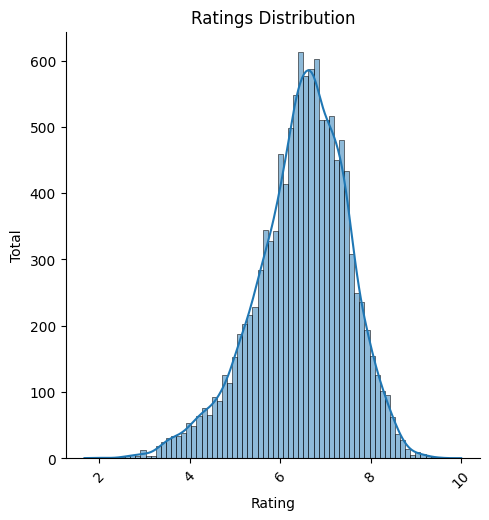

In [14]:
sns.displot(data=anime_df, x='rating',kde=True)

plt.xlabel('Rating')
plt.ylabel('Total')
plt.title('Ratings Distribution')
plt.xticks(rotation=45)

plt.show()

In [15]:
anime_df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [16]:
anime_df['genre'].fillna('Unknown',inplace=True)

C:\Users\roysu\AppData\Local\Temp\ipykernel_10364\1387451100.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  anime_df['genre'].fillna('Unknown',inplace=True)


In [17]:
anime_df['type'].fillna(anime_df['type'].mode()[0],inplace=True)

C:\Users\roysu\AppData\Local\Temp\ipykernel_10364\2564405325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  anime_df['type'].fillna(anime_df['type'].mode()[0],inplace=True)


In [18]:
anime_df.isnull().sum()

anime_id      0
name          0
genre         0
type          0
episodes      0
rating      230
members       0
dtype: int64

In [19]:
rating_df.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [20]:
anime_df[anime_df['name'].duplicated(keep=False)]

,anime_id,name,genre,type,episodes,rating,members
10140,22399,Saru Kani Gassen,Kids,OVA,1,5.23,62
10141,30059,Saru Kani Gassen,Drama,Movie,1,4.75,76
10193,33193,Shi Wan Ge Leng Xiaohua,"Comedy, Parody",ONA,12,6.67,114
10194,33195,Shi Wan Ge Leng Xiaohua,"Action, Adventure, Comedy, Fantasy, Parody",Movie,1,7.07,110


In [21]:
rating_df.duplicated().sum()

1

In [22]:
rating_df.drop_duplicates(keep='first',inplace=True)

In [23]:
anime_df.duplicated().sum()

0

In [24]:
rating_df.duplicated().sum()

0

In [44]:
data = pd.merge(anime_df,rating_df,on='anime_id')
data = data.rename(columns={'rating_x':'ratings','rating_y':'user_rating'})

In [45]:
data.head()

,anime_id,name,genre,type,episodes,ratings,members,user_id,user_rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,278,-1


## Exploratory data Analysis ##

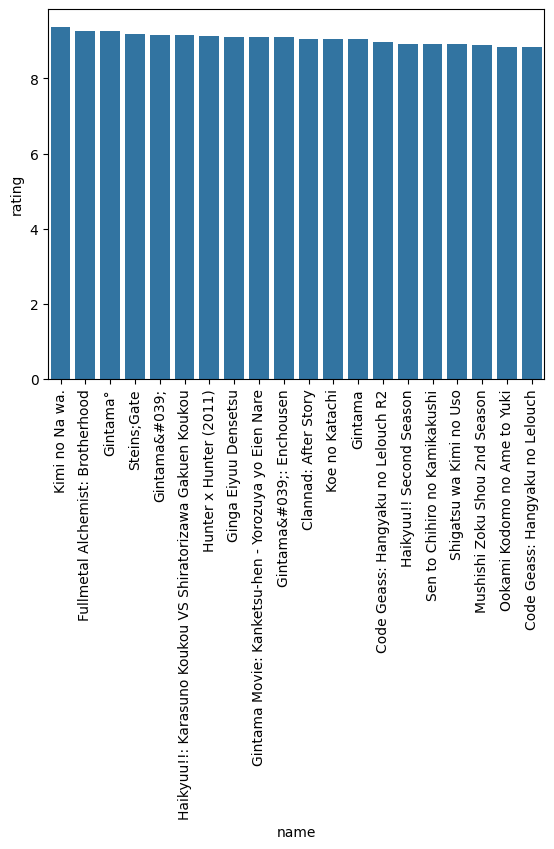

In [27]:
#Top animes by ratings

sns.barplot(x=anime_df['name'][:20],y=anime_df['rating'][:20])
plt.xticks(rotation=90)
plt.show()

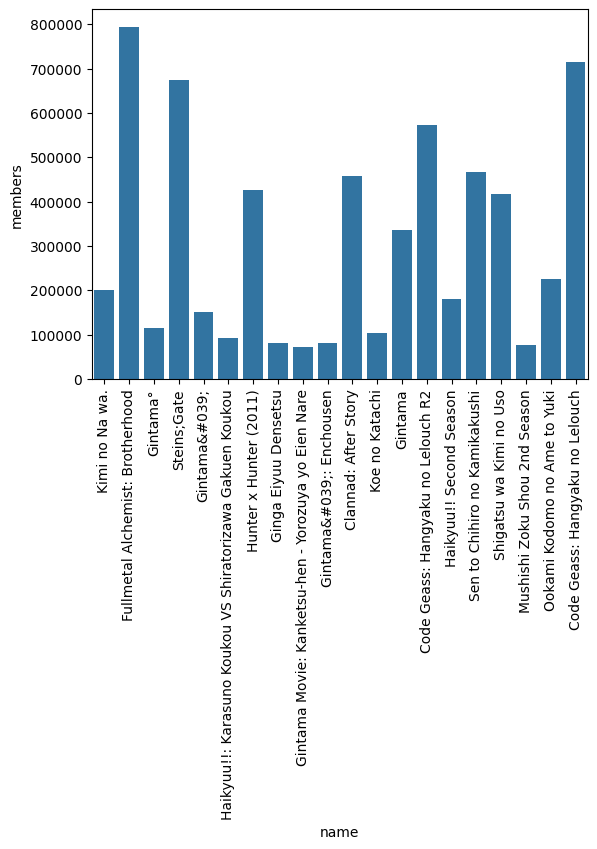

In [28]:
#Top Anime by community

sns.barplot(x=anime_df['name'][:20],y=anime_df['members'][:20])
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='type', ylabel='count'>

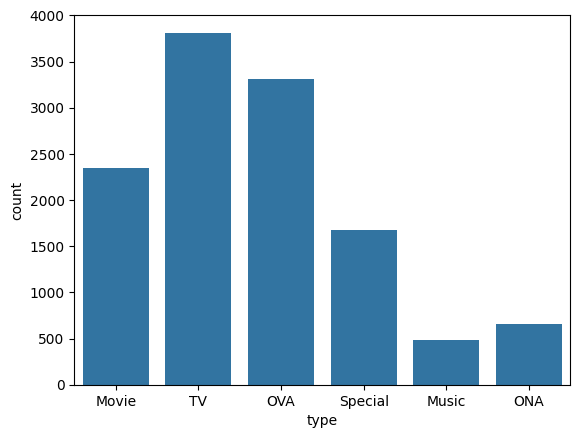

In [29]:
sns.countplot(x=anime_df['type'])

In [30]:
anime_df['type'].value_counts()

type
TV         3812
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

<Axes: xlabel='user_rating'>

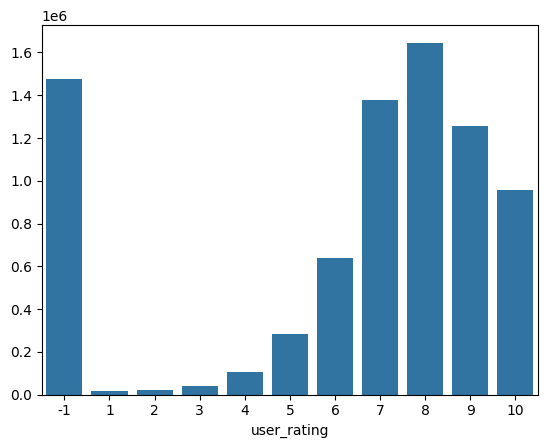

In [31]:
sns.barplot(x=data['user_rating'].value_counts().index,y=data['user_rating'].value_counts().values)

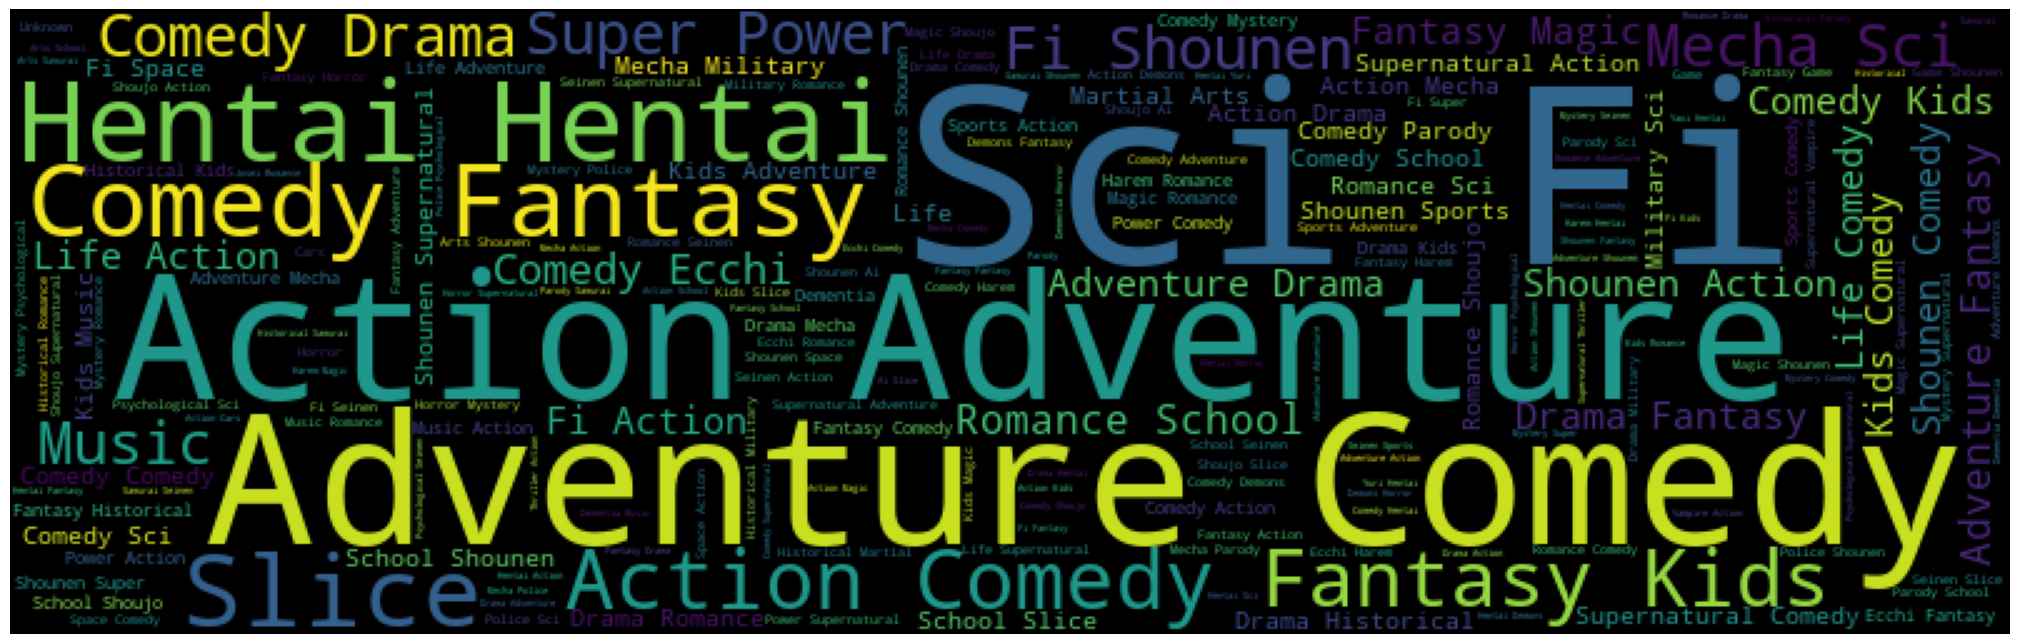

In [32]:
from wordcloud import WordCloud

wordcloud = WordCloud(width = 800, height = 250,max_font_size=100).generate(anime_df["genre"].str.cat(sep=", | , | ,"))

plt.figure(figsize = (20, 8)) 
plt.imshow(wordcloud)
plt.axis("off")
plt.margins(x = 0, y = 0)
plt.tight_layout(pad = 0) 
plt.show()

Exploratory Data Analysis insights

- Top anime by ratings for 20 shows kiminonawa has highest rating 
- Top anime by community 
- Type TV has more anime aired than evrything
- 6-10 ratings are give users shows positive rating for many animes but they are large number of -1 which shows that user viewed anime but didnot rate it so drop
- Word Cloud shows some famous genre

## Data Preprocessing ##

In [33]:
data.head()

,anime_id,name,genre,type,episodes,ratings,members,user_id,user_rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,278,-1


In [46]:
data['user_rating'].replace(-1,np.nan,inplace=True)

C:\Users\roysu\AppData\Local\Temp\ipykernel_10364\1178170502.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['user_rating'].replace(-1,np.nan,inplace=True)


In [47]:
data.dropna(axis=0,inplace=True)

In [48]:
data

,anime_id,name,genre,type,episodes,ratings,members,user_id,user_rating
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5.0
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10.0
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10.0
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10.0
5,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10.0
...,...,...,...,...,...,...,...,...,...
7813712,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211,58483,1.0
7813715,5543,Under World,Hentai,OVA,1,4.28,183,49503,4.0
7813716,5543,Under World,Hentai,OVA,1,4.28,183,58483,1.0
7813719,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219,49503,6.0


In [37]:
data.loc[data['name'].str.contains(r'[^\x00-\x7F]', regex=True, na=False), 'name']

26774         Gintama°
26775         Gintama°
26779         Gintama°
26780         Gintama°
26781         Gintama°
              ...     
7813541    Battle Can²
7813542    Battle Can²
7813544    Battle Can²
7813545    Battle Can²
7813546    Battle Can²
Name: name, Length: 225190, dtype: object

In [38]:
import re
def text_cleaning(text):
    text = re.sub(r'&quot;', '', text)
    text = re.sub(r'.hack//', '', text)
    text = re.sub(r'&#039;', '', text)
    text = re.sub(r'A&#039;s', '', text)
    text = re.sub(r'I&#039;', 'I\'', text)
    text = re.sub(r'&amp;', 'and', text)
    
    return text

data["name"] = data["name"].apply(text_cleaning)

In [49]:
review_count_data = data.groupby('anime_id').size().reset_index()
review_count_data.columns = ['anime_id','review_count']


data = data.merge(review_count_data,on='anime_id')

data.head()

,anime_id,name,genre,type,episodes,ratings,members,user_id,user_rating,review_count
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5.0,1961
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10.0,1961
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10.0,1961
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10.0,1961
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10.0,1961


## Model Building ##


**Website**
- ~~Top 25 anime of all time in home page~~
- ~~Top anime by community~~ 
- Recommender System 
    - ~~Content Based~~
    - ~~Collaborative~~
     

In [ ]:
# Top 100 animes of all time by ratings
top_anime_ratings = (
    data.groupby(['name','type'])['ratings']
    .mean()
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
)

In [58]:
top_anime_ratings.head()

,name,type,ratings
0,Kimi no Na wa.,Movie,9.37
1,Fullmetal Alchemist: Brotherhood,TV,9.26
2,Gintama°,TV,9.25
3,Steins;Gate,TV,9.17
4,Gintama&#039;,TV,9.16


In [61]:
# Top animes by community
top_animes_community = data.groupby('name')['members'].mean().sort_values(ascending=False).head(20)

In [63]:
# Recommendation system using Content Based Filtering

anime_copy = data[['anime_id','name','genre','ratings','members']].drop_duplicates()
anime_copy = anime_copy.dropna(subset=['genre'])

In [64]:
anime_copy.head()

,anime_id,name,genre,ratings,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",9.37,200630
1961,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,793665
23455,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,114262
24643,9253,Steins;Gate,"Sci-Fi, Thriller",9.17,673572
41794,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,151266


In [69]:
genres = set()
for genre_list in anime_copy['genre']:
    for genre in genre_list.split(', '):
        genres.add(genre)
genres = sorted(list(genres))

In [70]:
genres

['Action',
 'Adventure',
 'Cars',
 'Comedy',
 'Dementia',
 'Demons',
 'Drama',
 'Ecchi',
 'Fantasy',
 'Game',
 'Harem',
 'Hentai',
 'Historical',
 'Horror',
 'Josei',
 'Kids',
 'Magic',
 'Martial Arts',
 'Mecha',
 'Military',
 'Music',
 'Mystery',
 'Parody',
 'Police',
 'Psychological',
 'Romance',
 'Samurai',
 'School',
 'Sci-Fi',
 'Seinen',
 'Shoujo',
 'Shoujo Ai',
 'Shounen',
 'Shounen Ai',
 'Slice of Life',
 'Space',
 'Sports',
 'Super Power',
 'Supernatural',
 'Thriller',
 'Unknown',
 'Vampire',
 'Yaoi',
 'Yuri']

In [78]:
def recommend_by_genre(selected_genres):
    filtered_genre = anime_df.copy()
    filtered_genre = filtered_genre[filtered_genre['members'] > 50000]
    for genre in selected_genres:
        filtered_genre = filtered_genre[filtered_genre['genre'].str.contains(genre)]
    
    filtered_genre = filtered_genre.sort_values(by='rating', ascending=False)

    return filtered_genre[['name','genre','rating']].head(10)
        


In [84]:
anime_df['genre'].value_counts()

genre
Hentai                                                  823
Comedy                                                  523
Music                                                   301
Kids                                                    199
Comedy, Slice of Life                                   179
                                                       ... 
Adventure, Drama, Fantasy, Game, Sci-Fi                   1
Adventure, Demons, Fantasy, Historical                    1
Action, Comedy, Drama, Mecha, Music, Sci-Fi, Shounen      1
Action, Comedy, Fantasy, Mecha, Sci-Fi, Shounen           1
Hentai, Slice of Life                                     1
Name: count, Length: 3265, dtype: int64

In [89]:
recommend_by_genre(['Comedy'])

,name,genre,rating
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",9.25
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",9.16
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",9.15
9,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",9.11
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",9.10
12,Gintama,"Action, Comedy, Historical, Parody, Samurai, S...",9.04
14,Haikyuu!! Second Season,"Comedy, Drama, School, Shounen, Sports",8.93
20,Hajime no Ippo,"Comedy, Drama, Shounen, Sports",8.83
22,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",8.82
23,One Punch Man,"Action, Comedy, Parody, Sci-Fi, Seinen, Super ...",8.82


In [90]:
# Recommendation system using collaborative filtering

anime_df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [98]:
anime_counts = data['name'].value_counts()

popular_anime = anime_counts[anime_counts >= 50].index

anime_user_data = data[data['name'].isin(popular_anime)]

user_counts = anime_user_data['user_id'].value_counts()

active_users = user_counts[user_counts >= 50].index

anime_user_data = anime_user_data[anime_user_data['user_id'].isin(active_users)]

In [99]:
anime_user_data

,anime_id,name,genre,type,episodes,ratings,members,user_id,user_rating,review_count
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5.0,1961
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10.0,1961
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10.0,1961
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10.0,1961
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10.0,1961
...,...,...,...,...,...,...,...,...,...,...
6336879,1639,Boku no Pico,"Hentai, Yaoi",OVA,1,5.13,57355,73328,2.0,1783
6336880,1639,Boku no Pico,"Hentai, Yaoi",OVA,1,5.13,57355,73329,6.0,1783
6336881,1639,Boku no Pico,"Hentai, Yaoi",OVA,1,5.13,57355,73348,4.0,1783
6336882,1639,Boku no Pico,"Hentai, Yaoi",OVA,1,5.13,57355,73389,7.0,1783


In [103]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
anime_enc = LabelEncoder()

anime_user_data['user'] = user_enc.fit_transform(anime_user_data['user_id'])
anime_user_data['anime'] = anime_enc.fit_transform(anime_user_data['anime_id'])

from scipy.sparse import csr_matrix

ratings_matrix = csr_matrix(
    (
        anime_user_data['user_rating'],
        (anime_user_data['user'], anime_user_data['anime'])
    )
)

from sklearn.metrics.pairwise import cosine_similarity

anime_similarity = cosine_similarity(ratings_matrix.T)

In [106]:
anime_titles = anime_user_data.drop_duplicates('anime')[['anime','name']].set_index('anime')
anime_index = dict(zip(anime_titles['name'], anime_titles.index))
def recommend(anime_name):

    idx = anime_index[anime_name]

    sim_scores = list(enumerate(anime_similarity[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:11]

    anime_indices = [i[0] for i in sim_scores]

    return anime_titles.loc[anime_indices]['name']

In [ ]:
recommend('Naruto')

anime
1277                            Death Note
3653                      Sword Art Online
2569      Fullmetal Alchemist: Brotherhood
1309       Code Geass: Hangyaku no Lelouch
98                     Fullmetal Alchemist
4093                    Shingeki no Kyojin
239                                 Bleach
3321                        Ao no Exorcist
2036    Code Geass: Hangyaku no Lelouch R2
197                             Elfen Lied
Name: name, dtype: object

In [109]:
import pickle
pickle.dump(anime_user_data, open('anime_user_data.pkl', 'wb'))
pickle.dump(data, open('anime_data.pkl', 'wb'))
pickle.dump(ratings_matrix, open('ratings_matrix.pkl', 'wb'))
pickle.dump(anime_similarity, open('similarity.pkl', 'wb'))
pickle.dump(anime_df, open('anime.pkl', 'wb'))
pickle.dump(rating_df, open('ratings.pkl', 'wb'))

In [110]:
data

,anime_id,name,genre,type,episodes,ratings,members,user_id,user_rating,review_count
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,99,5.0,1961
1,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,152,10.0,1961
2,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,244,10.0,1961
3,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,271,10.0,1961
4,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,322,10.0,1961
...,...,...,...,...,...,...,...,...,...,...
6337228,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211,58483,1.0,2
6337229,5543,Under World,Hentai,OVA,1,4.28,183,49503,4.0,2
6337230,5543,Under World,Hentai,OVA,1,4.28,183,58483,1.0,2
6337231,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219,49503,6.0,1
